In [31]:
%pip install Sastrawi nltk

Note: you may need to restart the kernel to use updated packages.


In [32]:
import re
import string
import pandas as pd
import nltk
import ast


# Download required NLTK data
nltk.download('punkt')

df = pd.read_csv('Dataset/raw_review.csv')
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\degap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,userName,score,at,content
0,Pengguna Google,4,2026-04-28 09:44:27,terlalu banyak iklan
1,Pengguna Google,1,2026-04-28 09:28:08,iklan lu terlalu berlebihan
2,Pengguna Google,5,2026-04-28 09:25:04,"ini bisa ngedengerin musik idola sendiri, poko..."
3,Pengguna Google,2,2026-04-28 09:22:43,jelek pas masuk aplikasinya sering delay dan l...
4,Pengguna Google,5,2026-04-28 09:19:08,"spotify, udah seperti bestie gua."


In [33]:
#label Data
def label_sentiment(score):
    if score >= 4:
        return 1    
    elif score <= 2:
        return 0
    else:
        return 2

df['label'] = df['score'].apply(label_sentiment)

# buang netral:
df = df[df['label'] != 2]
df.head()

,userName,score,at,content,label
0,Pengguna Google,4,2026-04-28 09:44:27,terlalu banyak iklan,1
1,Pengguna Google,1,2026-04-28 09:28:08,iklan lu terlalu berlebihan,0
2,Pengguna Google,5,2026-04-28 09:25:04,"ini bisa ngedengerin musik idola sendiri, poko...",1
3,Pengguna Google,2,2026-04-28 09:22:43,jelek pas masuk aplikasinya sering delay dan l...,0
4,Pengguna Google,5,2026-04-28 09:19:08,"spotify, udah seperti bestie gua.",1


In [34]:
#hapus kolom yang tidak diperlukan
df.drop(['userName', 'at'], axis=1, inplace=True)
df.head()

,score,content,label
0,4,terlalu banyak iklan,1
1,1,iklan lu terlalu berlebihan,0
2,5,"ini bisa ngedengerin musik idola sendiri, poko...",1
3,2,jelek pas masuk aplikasinya sering delay dan l...,0
4,5,"spotify, udah seperti bestie gua.",1


In [35]:
#case folding
df['content'] = df['content'].str.lower()
df.head()

,score,content,label
0,4,terlalu banyak iklan,1
1,1,iklan lu terlalu berlebihan,0
2,5,"ini bisa ngedengerin musik idola sendiri, poko...",1
3,2,jelek pas masuk aplikasinya sering delay dan l...,0
4,5,"spotify, udah seperti bestie gua.",1


In [36]:
#hapus url dari komentar
def remove_url(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)

df['content'] = df['content'].apply(remove_url)

In [37]:
#hapus emoticon pada komentar
def remove_emoticons(text):
    emoticon_pattern = re.compile("["
        u"\U0001F300-\U0001F9FF"  # emoticon & simbol extended
        u"\U0001F1E0-\U0001F1FF"  # bendera (iOS)
        u"\U00002500-\U00002BEF"  # simbol box drawing & piktograf
        u"\U00002702-\U000027B0"  # dingbat
        u"\U00002702-\U000027B0"  # dingbat
        u"\U000024C2-\U0001F251"  # simbol
        u"\U0001f926-\U0001f937"  # gesture
        u"\u200d"                 # zero-width joiner
        u"\u2640-\u2642"          # gender
        "]+", flags=re.UNICODE)
    return emoticon_pattern.sub(r'', text)

df['content'] = df['content'].apply(remove_emoticons)

In [38]:
#Hapus Tanda Baca dan kuadrat
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['content'] = df['content'].apply(remove_punctuation)

In [39]:
#hapus angka dalam komenar
def remove_numbers(text):
    return re.sub(r'\d+', '', text)
df['content'] = df['content'].apply(remove_numbers)

In [40]:
#normalisasi kata
normalization_dict = {
    "gk": "tidak",
    "ko": "kok",
    "ga": "tidak",
    "g": "tidak",
    "gak": "tidak",
    "ngak": "tidak",
    "ngakn": "tidak",
    "tdk": "tidak",
    "bgt": "banget",
    "yg": "yang",
    "dr": "dari",
    "tp": "tapi",
    "udh": "sudah",
    "tf": "transfer",
    "lbh": "lebih",
    "knp": "kenapa",
    "klo": "kalau",
    "dgn": "dengan",
    "sm": "sama",
    "sya": "saya",
    "skrg": "sekarang",
    "ni": "ini",
    "min": "admin",
    "tgl": "tanggal",
    "blm": "belum",
    "trs": "terus",
    "sy": "saya",
    "apk": "aplikasi",
    "gem": "game",
    "gj": "tidak jelas",
    "ml": "mobil legends",
    "tim": "team",
    "yg": "yang",
    "yng": "yang",
    "udhlah": "sudah",
    "b": "bisa",
    "boikotiklan": "boikot iklan",
    "bnyakjleq": "banyak iklan",
    "bagu": "bagus",
    "baguss": "bagus",
}

def normalize_text(text):
    return ' '.join([normalization_dict[word] if word in normalization_dict else word for word in text.split()])

df['content'] = df['content'].apply(normalize_text)

In [41]:
#hapus elongation pada kata
def remove_elongation(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)
df['content'] = df['content'].apply(remove_elongation)

In [42]:
#Stopword Removal
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

df['content'] = df['content'].apply(remove_stopwords)

In [43]:
#steming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()
df['content'] = df['content'].apply(stemmer.stem)


In [45]:
#tokenisasi
from nltk.tokenize import word_tokenize
df['tokens'] = df['content'].apply(word_tokenize)
df.head()

,score,content,label,tokens
0,4,terlalu banyak iklan,1,"[terlalu, banyak, iklan]"
1,1,iklan lu terlalu lebih,0,"[iklan, lu, terlalu, lebih]"
2,5,ngedengerin musik idola sendiri pokok its the ...,1,"[ngedengerin, musik, idola, sendiri, pokok, it..."
3,2,jelek pas masuk aplikasi sering delay lagu pla...,0,"[jelek, pas, masuk, aplikasi, sering, delay, l..."
4,5,spotify udah bestie gua,1,"[spotify, udah, bestie, gua]"


In [46]:
# Cek content kosong atau tokens kosong
print("Content kosong (setelah strip):")
empty_content = df[df['content'].str.strip() == '']
print(f"Jumlah rows dengan content kosong: {len(empty_content)}")
print(empty_content[['score', 'content', 'label', 'tokens']])

print("\n\nTokens kosong:")
empty_tokens = df[df['tokens'].apply(len) == 0]
print(f"Jumlah rows dengan tokens kosong: {len(empty_tokens)}")
print(empty_tokens[['score', 'content', 'label', 'tokens']])

Content kosong (setelah strip):
Jumlah rows dengan content kosong: 98
      score content  label tokens
20        5              1     []
121       5              1     []
141       5              1     []
149       5              1     []
171       5              1     []
...     ...     ...    ...    ...
3682      5              1     []
3692      5              1     []
3867      5              1     []
3940      5              1     []
3987      5              1     []

[98 rows x 4 columns]


Tokens kosong:
Jumlah rows dengan tokens kosong: 98
      score content  label tokens
20        5              1     []
121       5              1     []
141       5              1     []
149       5              1     []
171       5              1     []
...     ...     ...    ...    ...
3682      5              1     []
3692      5              1     []
3867      5              1     []
3940      5              1     []
3987      5              1     []

[98 rows x 4 columns]


In [47]:
# Hapus rows dengan content kosong
print(f"Total baris sebelum cleaning: {len(df)}")
df = df[df['content'].str.strip() != '']
print(f"Total baris setelah cleaning: {len(df)}")

# Reset index
df = df.reset_index(drop=True)
print(f"\nVerifikasi - Tokens kosong tersisa: {df['tokens'].apply(len).min()}")

Total baris sebelum cleaning: 3790
Total baris setelah cleaning: 3692

Verifikasi - Tokens kosong tersisa: 1


In [ ]:
# Filter tambahan: hapus juga rows dengan tokens kosong yang masih tersisa
print(f"Total baris sebelum filter tokens: {len(df)}")
df = df[df['tokens'].apply(len) > 0]
df = df.reset_index(drop=True)
print(f"Total baris setelah filter tokens: {len(df)}")

# Cek distribusi label
print(f"\nDistribusi label:")
print(df['label'].value_counts())

Total baris sebelum filter tokens: 3692
Total baris setelah filter tokens: 3692

Distribusi label:
label
1    2640
0    1052
Name: count, dtype: int64


In [49]:
#melihat persebaran label
df['label'].value_counts()

label
1    2640
0    1052
Name: count, dtype: int64

In [50]:
%pip install wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.


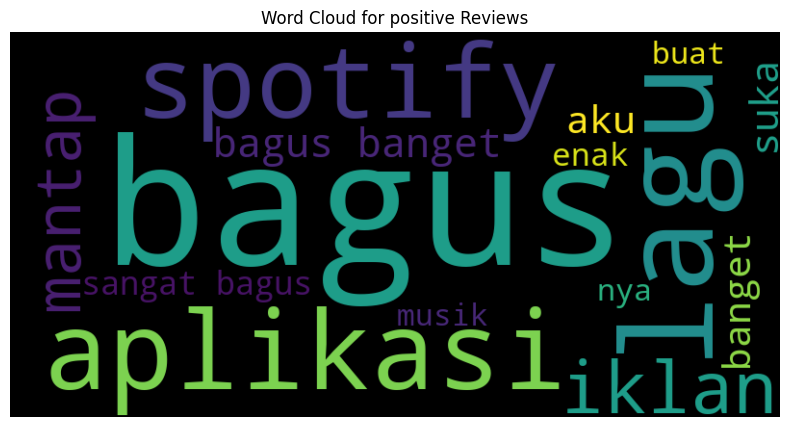

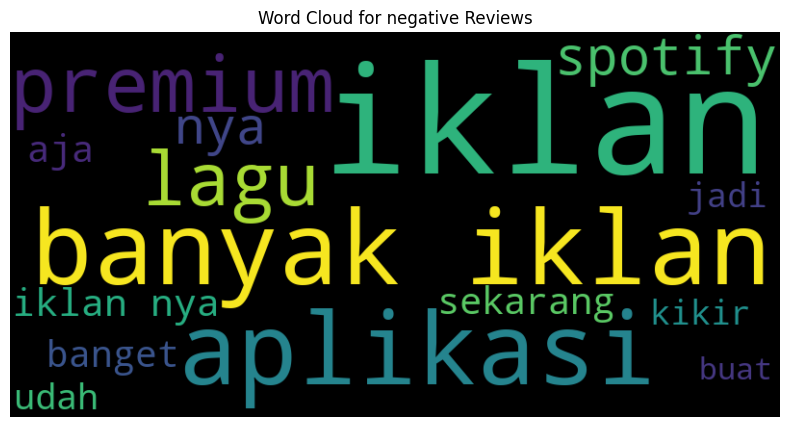

In [51]:
#Visualisasi word cloud untuk setiap label
from wordcloud import WordCloud
import matplotlib.pyplot as plt

label_names = {1: 'positive', 0: 'negative'}

labels = df['label'].unique()
for label in labels:
    text = ' '.join(df.loc[df['label'] == label, 'content'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, max_words=15).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {label_names[label]} Reviews')
    plt.show()

In [52]:
#dataset clean
df.to_csv("Dataset/dataset_clean(SMOTE).csv", index=False)

In [53]:
# Verifikasi final dataset yang disimpan
df_verify = pd.read_csv("Dataset/dataset_clean(SMOTE).csv")
print(f"Total baris dalam file yang disimpan: {len(df_verify)}")
print(f"Kolom dalam dataset: {list(df_verify.columns)}")
print(f"\nContent kosong: {(df_verify['content'].str.strip() == '').sum()}")
print(f"Score: {df_verify['score'].nunique()} unique values")
print(f"\nSample data:")
print(df_verify.head())

Total baris dalam file yang disimpan: 3692
Kolom dalam dataset: ['score', 'content', 'label', 'tokens']

Content kosong: 0
Score: 4 unique values

Sample data:
   score                                            content  label  \
0      4                               terlalu banyak iklan      1   
1      1                             iklan lu terlalu lebih      0   
2      5  ngedengerin musik idola sendiri pokok its the ...      1   
3      2  jelek pas masuk aplikasi sering delay lagu pla...      0   
4      5                            spotify udah bestie gua      1   

                                              tokens  
0                     ['terlalu', 'banyak', 'iklan']  
1                ['iklan', 'lu', 'terlalu', 'lebih']  
2  ['ngedengerin', 'musik', 'idola', 'sendiri', '...  
3  ['jelek', 'pas', 'masuk', 'aplikasi', 'sering'...  
4               ['spotify', 'udah', 'bestie', 'gua']  
